

# Lossy Dielectric Medium

For a material with a finite conductivity $\sigma$, we extend Ampere's law to include a term that represents the current driven by the electric field. The significance of this term differs from that of an additive current source discussed in previous chapters.

$$
\sigma \, \mathbf{E} + \epsilon \frac{\partial \mathbf{E}}{\partial t} = \nabla \times \mathbf{H} 
$$

When expanded into its components for a one-dimensional case, we get:

$$
\sigma \, E_z + \epsilon \frac{\partial E_z }{\partial t} = \frac{\partial H_y }{\partial x}
$$

To derive the FDTD update equation, we need to evaluate this relationship at the space-time coordinate $[m \Delta x, (q+1/2)\, \Delta t]$. While we can use standard finite-difference approximations for the derivatives, this leaves us with an $E_z$ term at time $(q+1/2)\, \Delta t$, a point in time where its value is not explicitly calculated in the Yee grid.

> **TODO:** Image

We can work around this problem by approximating the value of $E_z$ at the half-time step $(q+1/2)\, \Delta t$ as the average of its values at the adjacent full-time steps, $q \, \Delta t$ and $(q+1)\, \Delta t$.

$$
E_z^{q+1/2}[m] \approx \frac{E_z^{q+1}[m] + E_z^{q}[m]}{2}
$$

Substituting this approximation and the finite-difference derivatives into the 1D equation gives us the discrete form:

$$
\sigma \frac{E_z^{q+1}[m] + E_z^{q}[m]}{2} + \epsilon \frac{E_z^{q+1}[m] - E_z^{q}[m]}{\Delta t} = \frac{H_y^{q + 1/2}[m+1/2] - H_y^{q+1/2}[m-1/2] }{\Delta x}
$$

After solving for the future electric field value, $E_z^{q+1}[m]$, the final update equation takes the following form:

$$
E_z^{q+1}[m] = \left( \frac{1 - \frac{\sigma \Delta t}{2 \epsilon}}{1 + \frac{\sigma \Delta t}{2 \epsilon}} \right)
E_z^{q}[m] 
+ \left( \frac{ \frac{\Delta t}{\epsilon \, \Delta x} }{1 + \frac{\sigma \Delta t}{2 \epsilon}} \right)
\big({H_y^{q + 1/2}[m + 1/2] - H_y^{q+1/2}[m-1/2] } \big)
$$

This equation introduces two new multiplicative coefficients that depend on the conductivity $\sigma$. The first coefficient acts as a decay factor on the previous electric field value, modeling the energy loss in the material.




In previous chapters, the space-time relationships were expressed as a ratio using the **Courant number**. However, the equation for a lossy medium now contains the term:

$$
\frac{\sigma \, \Delta t}{2 \, \epsilon}
$$

This term requires an **explicit declaration of the time step** ($\Delta t$) in the simulation code.

Later, we will show how this limitation can be eliminated by using certain material parameters.

In [5]:
import matplotlib.pyplot as plt

def tm_plot(times, r):
    """
    Plot Ez field snapshots at selected time steps.

    Parameters
    ----------
    times : list of int
        Time steps to plot.
    r : ndarray
        2D array of shape (time, nodes) containing Ez values.
    """
    plt.figure(figsize=(10, 6))

    for i, t in enumerate(times):
        plt.subplot(len(times), 1, i + 1)
        plt.plot(r[t, :], "r-")
        plt.ylim(-1.1, 1.1)
        plt.xlim(0, r.shape[1])
        plt.legend([f"t={t}"])
        plt.grid(True)

    plt.tight_layout()
    plt.show()


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def wv_plot(time, nodes, r):
    """
    Plot a wave propagation diagram over time and space.
    
    Parameters:
    - time: number of time steps
    - nodes: number of spatial nodes
    - r: 2D array (time x nodes) containing Ez values
    """
    plt.figure(figsize=(10, 6))
    
    # Normalize for better visualization
    r_norm = r / np.max(np.abs(r))
    
    # Plot each time step offset for a "stacked" wave effect
    for t in range(0, time, int(time/20)):
        plt.plot(r_norm[t, :] + t * 0.05, label=f"t={t}")
    
    plt.xlabel("X")
    plt.ylabel("Amplitude + Time offset")
    plt.title("Wave propagation over time")
    plt.grid(True)
    plt.show()

# Example usage with your generated array `r`
nodes = 200
time = 200
# Assuming `r` is already filled with Ez values from your simulation
# wv_plot(time, nodes, r)


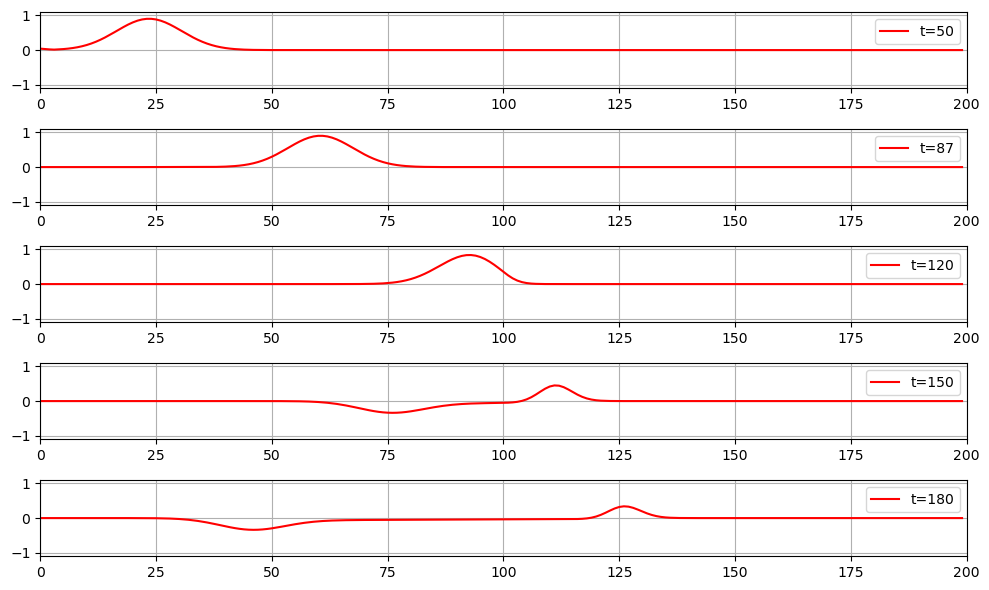

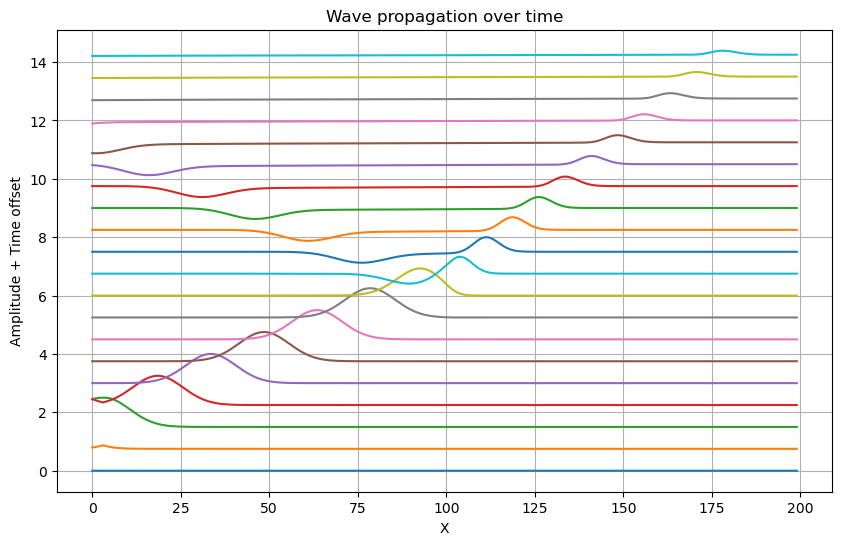

In [6]:

%matplotlib inline
from scipy import *
import matplotlib.pyplot as plt
import numpy as np

nodes = 200
time = 300
ez = np.zeros(nodes)
hy = np.zeros(nodes)
loss = 0.01
z0 = 377.0
Sc = 1.0

lse = np.ones(nodes)
lsh = np.ones(nodes)*z0

for i in range(100,nodes):
    lse[i] = (1 - loss) / (1 + loss)
    lsh[i] = z0 / (1 + loss) / 4.
    
r = np.zeros((time, nodes))                             # pole vysledkov

for t in range(time):
    ez[0] = ez[1]
    
    for m in range(1,nodes):                       
        ez[m] = lse[m] * ez[m] + lsh[m] *(hy[m] - hy[m - 1]) #* z0 # * Sc   # aktualizacia Ez
        
    ez[3] += np.exp(-(t - 30.)**2 / 100.)*1.8
    
    for m in range(nodes-1):                      
        hy[m] = hy[m] + (ez[m + 1] - ez[m]) / z0 #* Sc    # aktualizacia Hy
        
    r[t,:] += ez

tm_plot([50, 87, 120, 150, 180], r)
wv_plot(time, nodes, r)  

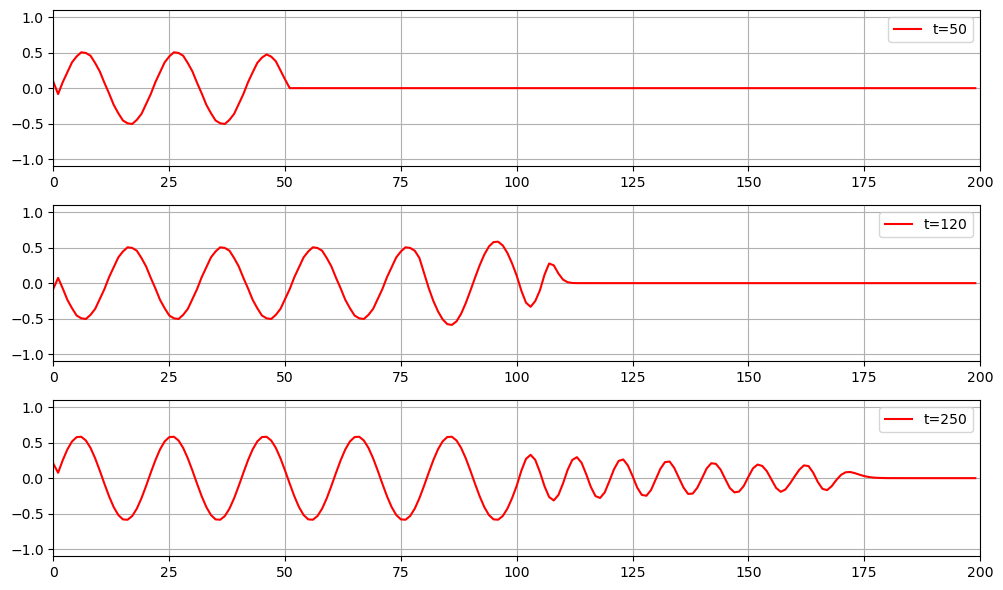

In [8]:

%matplotlib inline
from scipy import *
import matplotlib.pyplot as plt
import numpy as np

nodes = 200
time = 300
ez = np.zeros(nodes)
hy = np.zeros(nodes)
loss = 0.005
z0 = 377.0
Sc = 1.0

lse = np.ones(nodes)
lsh = np.ones(nodes)*z0

for i in range(100,nodes):
    lse[i] = (1 - loss) / (1 + loss)
    lsh[i] = z0 / (1 + loss) / 4.
    
r = np.zeros((time, nodes))                             # pole vysledkov

for t in range(time):
    ez[0] = ez[1]
    
    for m in range(1,nodes):                       
        ez[m] = lse[m] * ez[m] + lsh[m] *(hy[m] - hy[m - 1]) #* z0 # * Sc   # aktualizacia Ez
        
    ez[1] += np.sin(2*np.pi*0.05*t)*(1-np.exp(-t*0.5))  #exp(-(t - 30.)**2 / 100.)*1.8
    
    for m in range(nodes-1):                      
        hy[m] = hy[m] + (ez[m + 1] - ez[m]) / z0 #* Sc    # aktualizacia Hy
        
    r[t,:] += ez


tm_plot([50, 120, 250], r)